# MMM Agent Benchmark Report

This notebook summarizes benchmark outputs generated by `benchmark/cli.py`.

Expected files in `benchmark/results/latest/`:
- `run_results.csv`
- `paired_deltas.csv`
- `task_summary.csv`
- `benchmark_summary.csv`

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from pymc_marketing.paths import root

results_dir = root / "benchmark" / "results" / "latest"

if not (results_dir / "run_results.csv").exists():
    raise FileNotFoundError(
        "Benchmark results not found. Run benchmark first, e.g. "
        "`python -m benchmark.cli --output-dir benchmark/results/latest`"
    )

run_df = pd.read_csv(results_dir / "run_results.csv")
paired_df = pd.read_csv(results_dir / "paired_deltas.csv")
task_df = pd.read_csv(results_dir / "task_summary.csv")
benchmark_df = pd.read_csv(results_dir / "benchmark_summary.csv")

print(f"Using results directory: {results_dir}")
run_df.head()

Using results directory: /Users/juanitorduz/Documents/pymc-marketing/benchmark/results/latest


,task_id,task_type,mode,seed,status,runtime_sec,dataset_path,sampler_nuts_sampler,sampler_chains,sampler_cores,...,metric_parameter_recovery_shared_key_count,metric_parameter_recovery_missing_estimate_count,metric_parameter_recovery_missing_truth_count,metric_roas_recovery_mae,metric_roas_recovery_rmse,metric_roas_recovery_median_ae,metric_roas_recovery_max_ae,metric_roas_recovery_shared_key_count,metric_roas_recovery_missing_estimate_count,metric_roas_recovery_missing_truth_count
0,mmm_case_study_1d,mmm_1d,baseline,42,success,5.424758,https://raw.githubusercontent.com/sibylhe/mmm_...,nutpie,14,14,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,mmm_case_study_1d,mmm_1d,skilled,42,success,5.952244,https://raw.githubusercontent.com/sibylhe/mmm_...,nutpie,14,14,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,mmm_multidimensional_recovery,mmm_multidimensional,baseline,42,success,5.424758,data/mmm_multidimensional_example.csv,nutpie,14,14,...,2.0,14.0,2.0,1.031333,1.036290,1.031333,1.132566,2.0,0.0,0.0
3,mmm_multidimensional_recovery,mmm_multidimensional,skilled,42,success,5.952244,data/mmm_multidimensional_example.csv,nutpie,14,14,...,2.0,14.0,2.0,1.021025,1.024510,1.021025,1.105461,2.0,0.0,0.0
4,mmm_roas_confounding_calibration,mmm_roas_confounding,baseline,42,success,5.888365,data/mmm_roas_data.csv,nutpie,14,14,...,2.0,0.0,0.0,713.009347,799.209312,713.009347,1074.053936,2.0,0.0,0.0


,mode,metric_crps_oos,metric_convergence_divergence_count,metric_crps_cv_mean,metric_crps_cv_std,metric_cv_n_folds,metric_crps_train_cv_mean,metric_crps_train_cv_std,metric_crps_test_cv_mean,metric_crps_test_cv_std,...,metric_parameter_recovery_missing_estimate_count,metric_parameter_recovery_missing_truth_count,metric_roas_recovery_mae,metric_roas_recovery_rmse,metric_roas_recovery_median_ae,metric_roas_recovery_max_ae,metric_roas_recovery_shared_key_count,metric_roas_recovery_missing_estimate_count,metric_roas_recovery_missing_truth_count,task_count
0,baseline,0.204896,0.0,0.204896,0.001572,3.666667,0.183796,0.001034,0.204896,0.001572,...,7.0,1.0,357.020340,400.122801,357.020340,537.593251,2.0,0.0,0.0,3
1,skilled,0.165150,0.0,0.165150,0.001045,3.666667,0.147011,0.000916,0.165150,0.001045,...,7.0,1.0,0.527682,0.529844,0.527682,0.573720,2.0,0.0,0.0,3


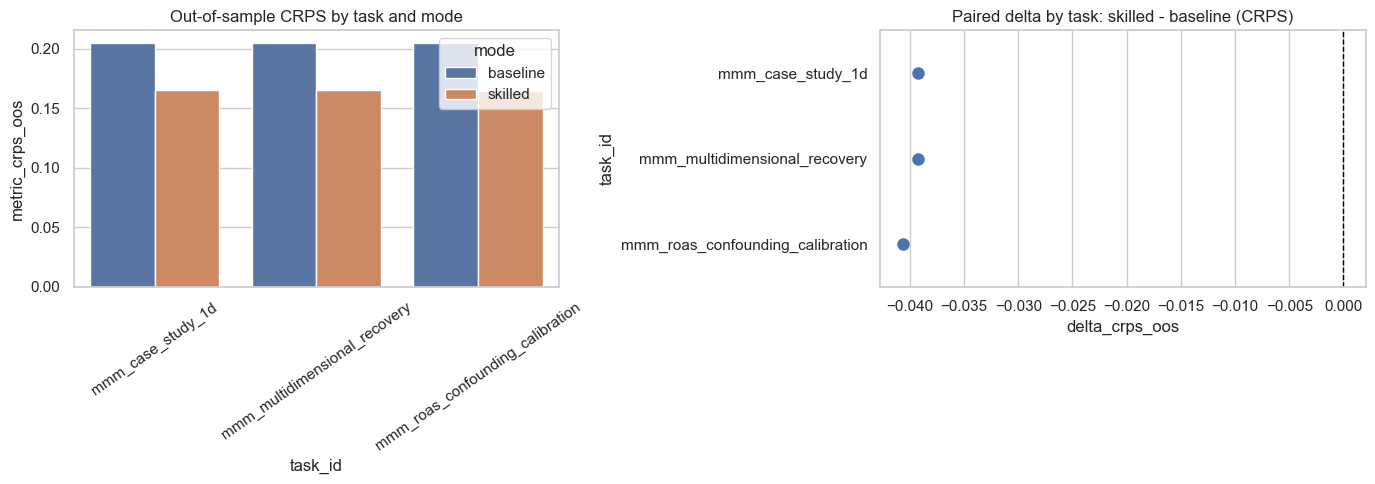

In [2]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=task_df,
    x="task_id",
    y="metric_crps_oos",
    hue="mode",
    ax=axes[0],
)
axes[0].set_title("Out-of-sample CRPS by task and mode")
axes[0].tick_params(axis="x", rotation=35)

if "delta_crps_oos" in paired_df.columns:
    # With very few paired points, a histogram is misleading.
    # Plot per-task deltas directly and include a zero-reference line.
    delta_df = paired_df[["task_id", "delta_crps_oos"]].copy()
    sns.stripplot(
        data=delta_df,
        y="task_id",
        x="delta_crps_oos",
        size=9,
        jitter=False,
        orient="h",
        ax=axes[1],
    )
    axes[1].axvline(0.0, color="black", linestyle="--", linewidth=1)
    axes[1].set_title("Paired delta by task: skilled - baseline (CRPS)")
    axes[1].set_xlabel("delta_crps_oos")
    axes[1].set_ylabel("task_id")
else:
    axes[1].text(0.1, 0.5, "delta_crps_oos not available", fontsize=12)
    axes[1].set_axis_off()

plt.tight_layout()
benchmark_df

,task_id,mode,metric_parameter_recovery_mae,metric_parameter_recovery_rmse,metric_roas_recovery_mae,metric_roas_recovery_rmse,metric_parameter_recovery_shared_key_count
2,mmm_multidimensional_recovery,baseline,0.118201,0.133611,1.031333,1.036290,2.0
3,mmm_multidimensional_recovery,skilled,0.118254,0.132059,1.021025,1.024510,2.0
4,mmm_roas_confounding_calibration,baseline,1.168412,1.187044,713.009347,799.209312,2.0
5,mmm_roas_confounding_calibration,skilled,0.006024,0.008201,0.034339,0.035178,2.0


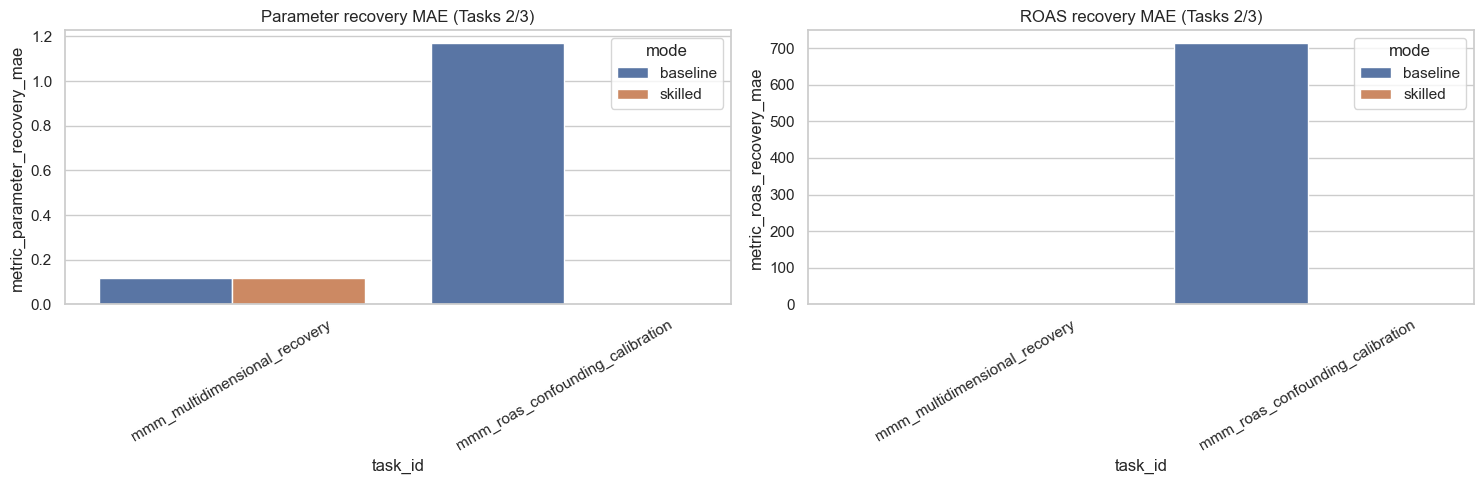

In [3]:
# Parameter recovery deep-dive (Tasks 2 and 3)
import json
from pathlib import Path

recovery_tasks = [
    "mmm_multidimensional_recovery",
    "mmm_roas_confounding_calibration",
]

recovery_df = run_df[run_df["task_id"].isin(recovery_tasks)].copy()

if not recovery_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    sns.barplot(
        data=recovery_df,
        x="task_id",
        y="metric_parameter_recovery_mae",
        hue="mode",
        ax=axes[0],
    )
    axes[0].set_title("Parameter recovery MAE (Tasks 2/3)")
    axes[0].tick_params(axis="x", rotation=30)

    sns.barplot(
        data=recovery_df,
        x="task_id",
        y="metric_roas_recovery_mae",
        hue="mode",
        ax=axes[1],
    )
    axes[1].set_title("ROAS recovery MAE (Tasks 2/3)")
    axes[1].tick_params(axis="x", rotation=30)
    plt.tight_layout()

records = []
for _, row in recovery_df.iterrows():
    artifact_path = Path(row["artifacts_path"])
    detail_path = artifact_path / "parameter_recovery_details.json"
    if not detail_path.exists():
        continue

    with open(detail_path, encoding="utf-8") as f:
        detail = json.load(f)

    errors = detail.get("error_by_key", {})
    if isinstance(errors, dict):
        for key, value in errors.items():
            records.append(
                {
                    "task_id": row["task_id"],
                    "mode": row["mode"],
                    "parameter_key": str(key),
                    "absolute_error": float(value),
                }
            )

error_df = pd.DataFrame(records)
if not error_df.empty:
    top_errors = (
        error_df.sort_values("absolute_error", ascending=False)
        .groupby(["task_id", "mode"], as_index=False)
        .head(8)
    )
    plt.figure(figsize=(12, 5))
    sns.barplot(
        data=top_errors,
        x="parameter_key",
        y="absolute_error",
        hue="mode",
    )
    plt.title("Top per-parameter absolute errors (Tasks 2/3)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

recovery_cols = [
    "task_id",
    "mode",
    "metric_parameter_recovery_mae",
    "metric_parameter_recovery_rmse",
    "metric_roas_recovery_mae",
    "metric_roas_recovery_rmse",
    "metric_parameter_recovery_shared_key_count",
]

available_recovery_cols = [col for col in recovery_cols if col in recovery_df.columns]
recovery_df[available_recovery_cols].sort_values(["task_id", "mode"])

,task_id,delta_crps_oos,delta_parameter_recovery_mae,delta_roas_recovery_mae,delta_cv_param_std_mean,fit_difference_explanation
0,mmm_case_study_1d,-0.039284,NaN,NaN,0.002312,Skilled improves out-of-sample CRPS. Skilled i...
1,mmm_multidimensional_recovery,-0.039284,0.000053,-0.010309,0.002312,Skilled improves out-of-sample CRPS. Skilled w...
2,mmm_roas_confounding_calibration,-0.040667,-1.162389,-712.975009,NaN,Skilled improves out-of-sample CRPS. Skilled i...


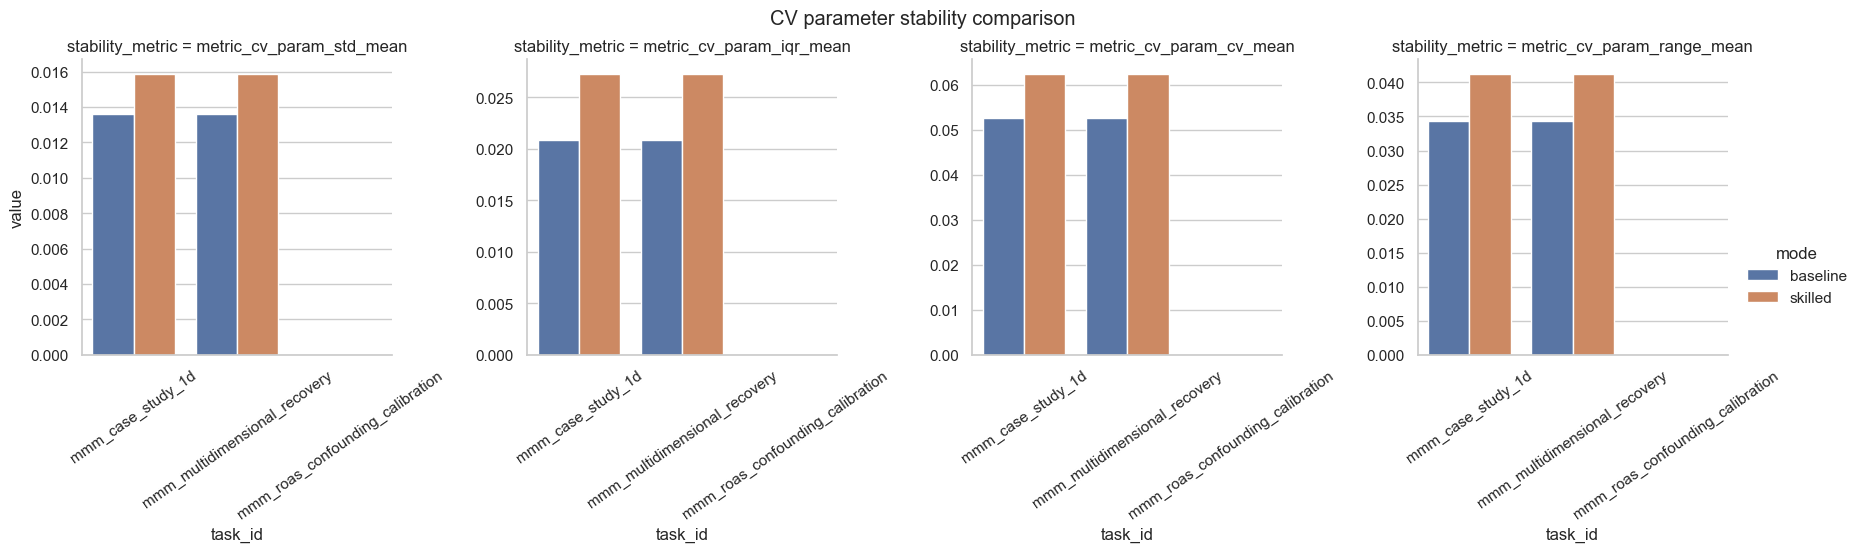

In [4]:
# CV parameter stability + fit-difference decomposition
stability_cols = [
    "metric_cv_param_std_mean",
    "metric_cv_param_iqr_mean",
    "metric_cv_param_cv_mean",
    "metric_cv_param_range_mean",
]

available_stability_cols = [col for col in stability_cols if col in run_df.columns]

if available_stability_cols:
    stability_long = run_df[["task_id", "mode", *available_stability_cols]].melt(
        id_vars=["task_id", "mode"],
        var_name="stability_metric",
        value_name="value",
    )
    g = sns.catplot(
        data=stability_long,
        x="task_id",
        y="value",
        hue="mode",
        col="stability_metric",
        kind="bar",
        sharey=False,
        height=4,
        aspect=1.1,
    )
    g.set_xticklabels(rotation=35)
    g.fig.suptitle("CV parameter stability comparison", y=1.03)


delta_cols = [
    "delta_crps_oos",
    "delta_parameter_recovery_mae",
    "delta_roas_recovery_mae",
    "delta_cv_param_std_mean",
]
available_delta_cols = [col for col in delta_cols if col in paired_df.columns]

fit_delta_df = paired_df[["task_id", *available_delta_cols]].copy()
fit_delta_df.head()


def _explain_row(row: pd.Series) -> str:
    messages = []

    delta_crps = row.get("delta_crps_oos")
    if pd.notna(delta_crps):
        if delta_crps < 0:
            messages.append("Skilled improves out-of-sample CRPS.")
        elif delta_crps > 0:
            messages.append("Skilled worsens out-of-sample CRPS.")

    delta_param = row.get("delta_parameter_recovery_mae")
    if pd.notna(delta_param):
        if delta_param < 0:
            messages.append("Skilled improves parameter recovery.")
        elif delta_param > 0:
            messages.append("Skilled worsens parameter recovery.")

    delta_roas = row.get("delta_roas_recovery_mae")
    if pd.notna(delta_roas):
        if delta_roas < 0:
            messages.append("Skilled improves ROAS recovery.")
        elif delta_roas > 0:
            messages.append("Skilled worsens ROAS recovery.")

    delta_stability = row.get("delta_cv_param_std_mean")
    if pd.notna(delta_stability):
        if delta_stability < 0:
            messages.append("Skilled is more parameter-stable across CV folds.")
        elif delta_stability > 0:
            messages.append("Skilled is less parameter-stable across CV folds.")

    if not messages:
        return "No clear signal (missing delta values)."
    return " ".join(messages)


fit_delta_df["fit_difference_explanation"] = fit_delta_df.apply(_explain_row, axis=1)
fit_delta_df.head()

In [5]:
# Posterior HDI parameter stability (fold-level)
import json
from pathlib import Path

import arviz as az
import numpy as np
import xarray as xr


def _iter_manifest_rows(df: pd.DataFrame):
    for _, row in df.iterrows():
        artifacts_path = Path(row.get("artifacts_path", ""))
        manifest_path = artifacts_path / "cv_posterior_manifest.json"
        if not manifest_path.exists():
            continue
        with open(manifest_path, encoding="utf-8") as f:
            manifest = json.load(f)
        for item in manifest:
            yield row, item


hdi_records = []
for row, item in _iter_manifest_rows(run_df):
    ds_path = Path(item.get("path", ""))
    if not ds_path.exists():
        continue
    ds = xr.open_dataset(ds_path)

    fold_idx = int(item.get("fold_idx", -1))
    for var_name, data_array in ds.data_vars.items():
        if "chain" not in data_array.dims or "draw" not in data_array.dims:
            continue

        non_sample_dims = [
            dim for dim in data_array.dims if dim not in {"chain", "draw"}
        ]
        if not non_sample_dims:
            samples = data_array.values.reshape(-1)
            hdi = az.hdi(samples, hdi_prob=0.94)
            hdi_records.append(
                {
                    "task_id": row["task_id"],
                    "mode": row["mode"],
                    "fold_idx": fold_idx,
                    "parameter": var_name,
                    "coordinate": "scalar",
                    "mean": float(np.mean(samples)),
                    "hdi_low": float(hdi[0]),
                    "hdi_high": float(hdi[1]),
                }
            )
            continue

        leading_dim = non_sample_dims[0]
        for coord in data_array.coords[leading_dim].values:
            subset = data_array.sel({leading_dim: coord}).values.reshape(-1)
            hdi = az.hdi(subset, hdi_prob=0.94)
            hdi_records.append(
                {
                    "task_id": row["task_id"],
                    "mode": row["mode"],
                    "fold_idx": fold_idx,
                    "parameter": var_name,
                    "coordinate": str(coord),
                    "mean": float(np.mean(subset)),
                    "hdi_low": float(hdi[0]),
                    "hdi_high": float(hdi[1]),
                }
            )

hdi_df = pd.DataFrame(hdi_records)
if hdi_df.empty:
    print("No posterior manifests found. Skipping HDI stability plots.")
else:
    hdi_df["label"] = hdi_df["parameter"] + "[" + hdi_df["coordinate"] + "]"

    for task_id in sorted(hdi_df["task_id"].unique()):
        task_subset = hdi_df[hdi_df["task_id"] == task_id]
        for label in sorted(task_subset["label"].unique())[:8]:
            plot_df = task_subset[task_subset["label"] == label].copy()
            if plot_df.empty:
                continue

            plt.figure(figsize=(10, 5))
            for mode, mode_df in plot_df.groupby("mode"):
                mode_df = mode_df.sort_values("fold_idx")
                x = mode_df["mean"].to_numpy()
                y = mode_df["fold_idx"].to_numpy()
                xerr = np.vstack(
                    [
                        x - mode_df["hdi_low"].to_numpy(),
                        mode_df["hdi_high"].to_numpy() - x,
                    ]
                )
                plt.errorbar(
                    x,
                    y,
                    xerr=xerr,
                    fmt="o",
                    capsize=3,
                    label=mode,
                )

            plt.title(f"Parameter Stability: {label} | task={task_id} (94% HDI)")
            plt.xlabel("posterior mean +/- 94% HDI")
            plt.ylabel("CV fold")
            plt.legend()
            plt.tight_layout()

hdi_df.head() if not hdi_df.empty else None

No posterior manifests found. Skipping HDI stability plots.


No cv_fold_crps artifacts found. Skipping fold CRPS trajectory section.


,task_id,mode,metric_crps_oos,metric_crps_train_cv_mean,metric_crps_test_cv_mean,metric_generalization_gap_mean,metric_cv_rhat_max,metric_cv_divergence_max,metric_runtime_sec,metric_runtime_per_fold_sec,metric_folds_per_second
0,mmm_case_study_1d,baseline,0.204816,0.183592,0.204816,0.021224,NaN,0.0,5.424758,1.084952,0.921700
1,mmm_case_study_1d,skilled,0.165531,0.147456,0.165531,0.018076,NaN,0.0,5.952244,1.190449,0.840019


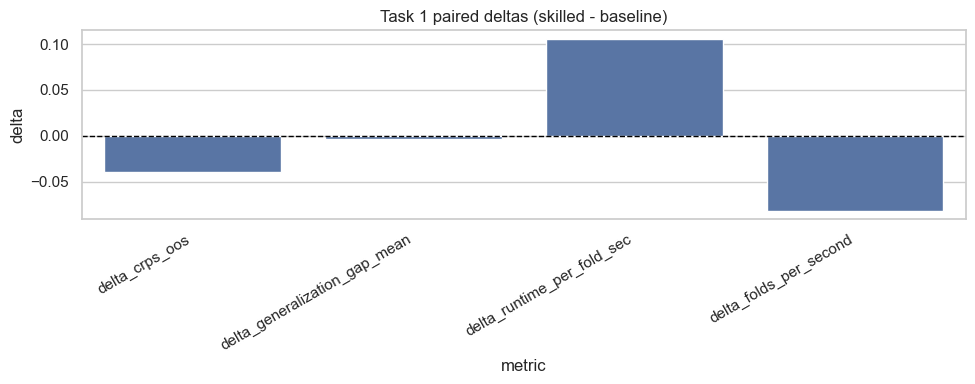

In [6]:
# Fold CRPS trajectories + Task 1 detailed comparison
import json
from pathlib import Path

fold_crps_records = []
for _, row in run_df.iterrows():
    crps_path = Path(row.get("artifacts_path", "")) / "cv_fold_crps.json"
    if not crps_path.exists():
        continue
    with open(crps_path, encoding="utf-8") as f:
        payload = json.load(f)
    for item in payload:
        fold_idx = int(item.get("fold_idx", -1))
        train = item.get("crps_train")
        test = item.get("crps_test")
        if train is not None:
            fold_crps_records.append(
                {
                    "task_id": row["task_id"],
                    "mode": row["mode"],
                    "fold_idx": fold_idx,
                    "split": "train",
                    "crps": float(train),
                }
            )
        if test is not None:
            fold_crps_records.append(
                {
                    "task_id": row["task_id"],
                    "mode": row["mode"],
                    "fold_idx": fold_idx,
                    "split": "test",
                    "crps": float(test),
                }
            )

fold_crps_df = pd.DataFrame(fold_crps_records)
if fold_crps_df.empty:
    print("No cv_fold_crps artifacts found. Skipping fold CRPS trajectory section.")
else:
    g = sns.relplot(
        data=fold_crps_df,
        x="fold_idx",
        y="crps",
        hue="split",
        style="mode",
        col="task_id",
        kind="line",
        markers=True,
        dashes=False,
        facet_kws={"sharey": False},
        height=4,
        aspect=1.1,
    )
    g.fig.suptitle("Fold CRPS trajectories (train/test)", y=1.05)


task1_id = "mmm_case_study_1d"
task1_df = run_df[run_df["task_id"] == task1_id].copy()
task1_pair_df = paired_df[paired_df["task_id"] == task1_id].copy()

if task1_df.empty:
    print("Task 1 rows not found in run_results.csv")
else:
    task1_cols = [
        "task_id",
        "mode",
        "metric_crps_oos",
        "metric_crps_train_cv_mean",
        "metric_crps_test_cv_mean",
        "metric_generalization_gap_mean",
        "metric_cv_rhat_max",
        "metric_cv_divergence_max",
        "metric_runtime_sec",
        "metric_runtime_per_fold_sec",
        "metric_folds_per_second",
    ]
    task1_cols = [col for col in task1_cols if col in task1_df.columns]
    display(task1_df[task1_cols].sort_values("mode"))

if not task1_pair_df.empty:
    delta_cols = [
        "delta_crps_oos",
        "delta_generalization_gap_mean",
        "delta_cv_rhat_max",
        "delta_runtime_per_fold_sec",
        "delta_folds_per_second",
    ]
    delta_cols = [col for col in delta_cols if col in task1_pair_df.columns]
    if delta_cols:
        delta_plot_df = task1_pair_df.melt(
            id_vars=["task_id", "seed"],
            value_vars=delta_cols,
            var_name="metric",
            value_name="delta",
        )
        plt.figure(figsize=(10, 4))
        sns.barplot(data=delta_plot_df, x="metric", y="delta")
        plt.axhline(0.0, color="black", linestyle="--", linewidth=1)
        plt.xticks(rotation=30, ha="right")
        plt.title("Task 1 paired deltas (skilled - baseline)")
        plt.tight_layout()

fold_crps_df.head() if not fold_crps_df.empty else None